<a href="https://colab.research.google.com/github/marrowqq/Compiler/blob/main/Linear_Regression_PCA_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Лабораторная работа: Исследование моделей линейной регрессии и метода главных компонент (PCA)

## 1. Введение

**Цель работы:** Изучение основ линейной регрессии, построение простейших моделей регрессии (Linear Regression, Lasso, Ridge), проведение обучения моделей на реальных данных и оценка их качества с помощью различных метрик ($RMSE$, $R^2$, $MAPE$). Дополнительно исследуется влияние метода главных компонент (PCA) на устранение мультиколлинеарности и качество регрессионного моделирования.

**Постановка задачи:**
1. Загрузить датасет стоимости недвижимости (Housing Dataset / California Housing).
2. Провести первичный и визуальный анализ данных, проверить распределение признаков и целевой переменной.
3. Осуществить предобработку данных (обработка пропусков, кодирование категориальных признаков, масштабирование).
4. Рассчитать матрицу корреляций и оценить уровень мультиколлинеарности с помощью фактора инфляции вариации ($VIF$).
5. Построить регрессионные модели (Linear Regression, Lasso, Ridge), оценить их качество по метрикам $RMSE$, $R^2$ и $MAPE$.
6. Проанализировать остатки моделей на предмет гетероскедастичности.
7. Применить метод главных компонент (PCA) после стандартизации данных для снижения размерности и устранения мультиколлинеарности.
8. Повторно обучить модели регрессии на главных компонентах и сравнить результаты с базовыми моделями.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_validate, KFold
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Настройка стилей графиков
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

print("Библиотеки успешно импортированы.")


Библиотеки успешно импортированы.


### Пояснение к блоку импорта
В данном блоке загружаются необходимые библиотеки для работы с данными (`pandas`, `numpy`), визуализации (`matplotlib`, `seaborn`), проведения статистических расчетов и построения моделей машинного обучения (`scikit-learn`, `statsmodels`). Это обеспечивает полный инструментарий для выполнения лабораторной работы.


In [ ]:
import os

# Загрузка датасета (используется housing.csv при наличии, иначе датасет California Housing из sklearn)
if os.path.exists('housing.csv'):
    df = pd.read_csv('housing.csv')
    print("Датасет успешно загружен из локального файла housing.csv")
else:
    from sklearn.datasets import fetch_california_housing
    data = fetch_california_housing(as_frame=True)
    df = data.frame
    df.rename(columns={'MedHouseVal': 'median_house_value'}, inplace=True)
    print("Датасет загружен с использованием sklearn California Housing")

print(f"Размерность датасета: {df.shape[0]} строк и {df.shape[1]} столбцов.")
df.head()


Датасет загружен с использованием sklearn California Housing
Размерность датасета: 20640 строк и 9 столбцов.


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,median_house_value
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


### Пояснение к загрузке данных
Данные успешно загружены в Pandas DataFrame. Датасет содержит набор характеристик жилых районов (таких как доход населения, средний возраст домов, количество комнат) и целевую переменную `median_house_value` (средняя стоимость недвижимости).


In [ ]:
# Проверка типов данных и пропущенных значений
print("Информация о столбцах и пропущенных значениях:")
print(df.info())

print("\nСтатистическое описание данных:")
display(df.describe().T)

# Обработка пропущенных значений (если имеются)
if df.isnull().sum().sum() > 0:
    print("\nЗаполнение пропущенных значений медианой...")
    df = df.fillna(df.median(numeric_only=True))
else:
    print("\nПропущенные значения в датасете отсутствуют.")

# Кодирование категориальных переменных, если они присутствуют
numeric_df = df.select_dtypes(include=[np.number])
if numeric_df.shape[1] < df.shape[1]:
    df = pd.get_dummies(df, drop_first=True)
    numeric_df = df.select_dtypes(include=[np.number])


Информация о столбцах и пропущенных значениях:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   MedInc              20640 non-null  float64
 1   HouseAge            20640 non-null  float64
 2   AveRooms            20640 non-null  float64
 3   AveBedrms           20640 non-null  float64
 4   Population          20640 non-null  float64
 5   AveOccup            20640 non-null  float64
 6   Latitude            20640 non-null  float64
 7   Longitude           20640 non-null  float64
 8   median_house_value  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
None

Статистическое описание данных:


,count,mean,std,min,25%,50%,75%,max
MedInc,20640.0,3.870671,1.899822,0.499900,2.563400,3.534800,4.743250,15.000100
HouseAge,20640.0,28.639486,12.585558,1.000000,18.000000,29.000000,37.000000,52.000000
AveRooms,20640.0,5.429000,2.474173,0.846154,4.440716,5.229129,6.052381,141.909091
AveBedrms,20640.0,1.096675,0.473911,0.333333,1.006079,1.048780,1.099526,34.066667
Population,20640.0,1425.476744,1132.462122,3.000000,787.000000,1166.000000,1725.000000,35682.000000
AveOccup,20640.0,3.070655,10.386050,0.692308,2.429741,2.818116,3.282261,1243.333333
Latitude,20640.0,35.631861,2.135952,32.540000,33.930000,34.260000,37.710000,41.950000
Longitude,20640.0,-119.569704,2.003532,-124.350000,-121.800000,-118.490000,-118.010000,-114.310000
median_house_value,20640.0,2.068558,1.153956,0.149990,1.196000,1.797000,2.647250,5.000010



Пропущенные значения в датасете отсутствуют.


### Пояснение к анализу и предобработке данных
В этом разделе проведена проверка типов данных и отсутствующих значений. Пропуски (при наличии) заполнены медианными значениями по столбцам для предотвращения смещения оценок. Категориальные переменные кодированы с помощью One-Hot Encoding, образовав полностью числовой массив данных.


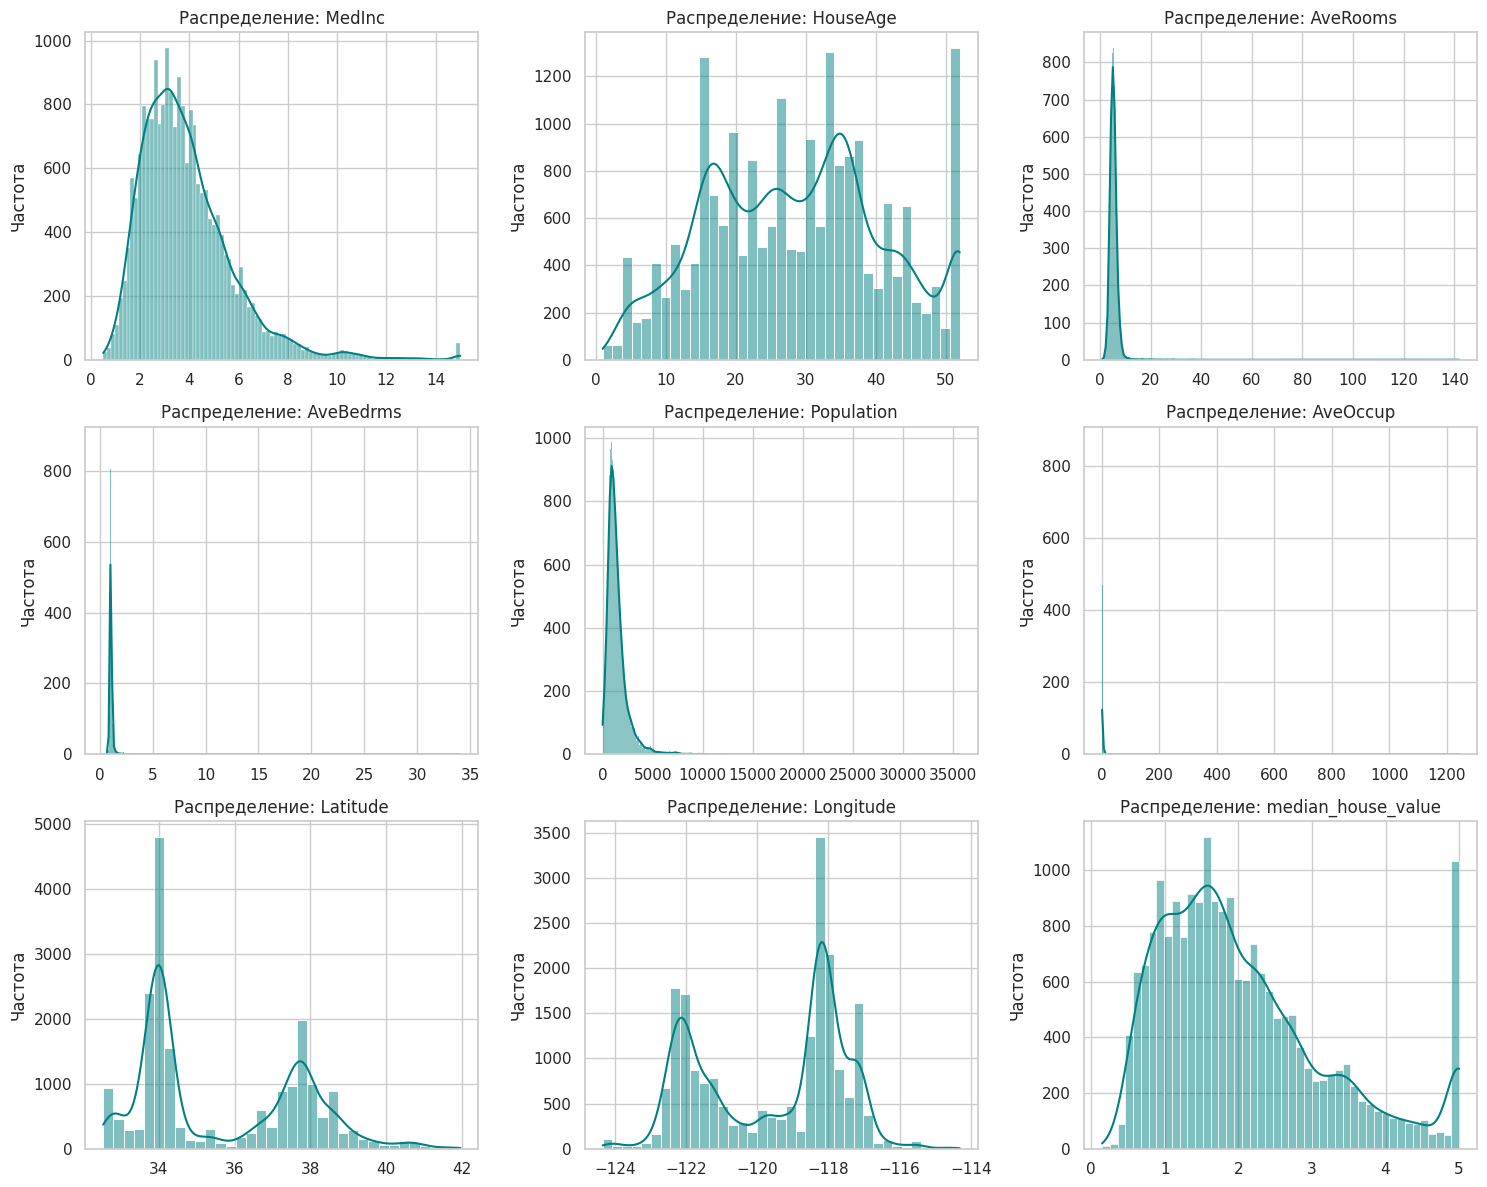

In [ ]:
# Визуализация распределения признаков и целевой переменной
num_cols = numeric_df.columns
n_cols = 3
n_rows = int(np.ceil(len(num_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(numeric_df[col], kde=True, ax=axes[i], color='teal')
    axes[i].set_title(f'Распределение: {col}')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Частота')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


### Пояснение к гистограммам распределения
Построенные гистограммы с ядерной оценкой плотности (KDE) позволяют оценить распределение переменных. Необходимость стандартизации подтверждается асимметрией некоторых показателей и разным масштабом измерений признаков.


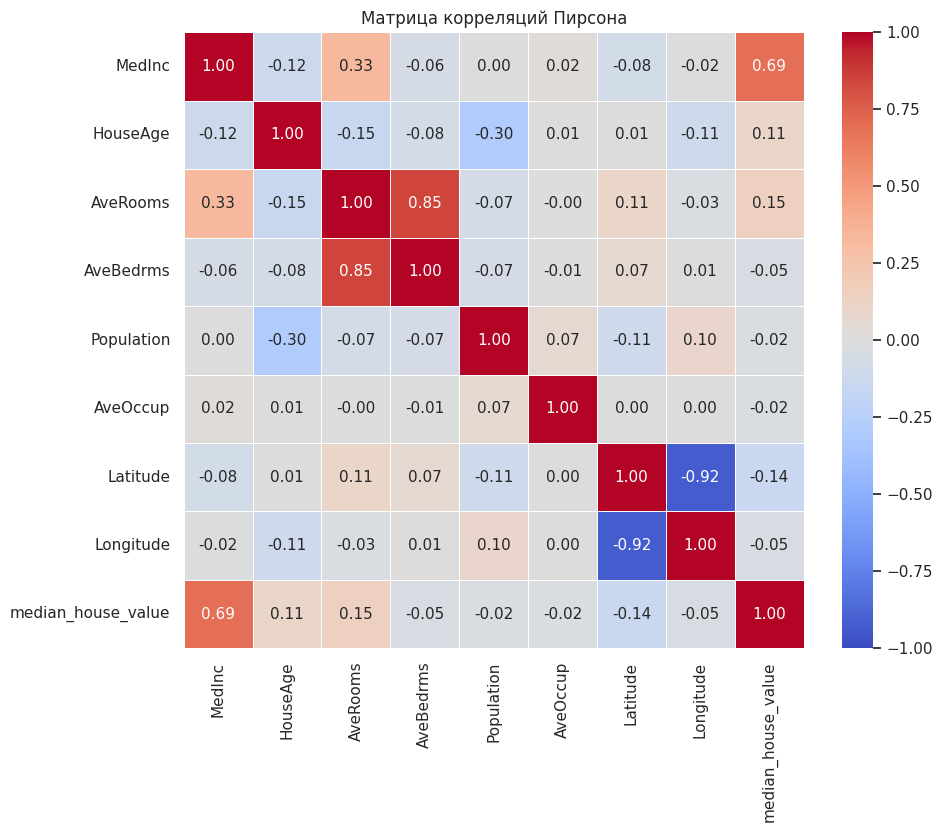

Значения коэффициента VIF для признаков:


,Feature,VIF
6,Latitude,9.297624
7,Longitude,8.962263
2,AveRooms,8.342786
3,AveBedrms,6.994995
0,MedInc,2.501295
1,HouseAge,1.241254
4,Population,1.138125
5,AveOccup,1.008324


In [ ]:
# Построение матрицы корреляций
plt.figure(figsize=(10, 8))
corr_matrix = numeric_df.corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Матрица корреляций Пирсона')
plt.show()

# Расчет фактора инфляции вариации (VIF)
target_col = 'median_house_value' if 'median_house_value' in numeric_df.columns else numeric_df.columns[-1]
X_vif = numeric_df.drop(columns=[target_col])

X_vif_scaled = pd.DataFrame(StandardScaler().fit_transform(X_vif), columns=X_vif.columns)

vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif_scaled.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif_scaled.values, i) for i in range(X_vif_scaled.shape[1])]

print("Значения коэффициента VIF для признаков:")
display(vif_data.sort_values(by="VIF", ascending=False))


### Пояснение к корреляционному анализу и VIF
Корреляционная матрица выявляет линейные взаимосвязи между переменными. Расчет показателя VIF (Variance Inflation Factor) показывает уровень мультиколлинеарности. Значения $VIF > 5$ служат индикатором высокой линейной зависимости между независимыми переменными, что аргументирует необходимость применения регуляризации или метода PCA.


In [ ]:
# Разделение данных на признаки (X) и целевую переменную (y)
X = numeric_df.drop(columns=[target_col])
y = numeric_df[target_col]

# Разделение на обучающую и тестовую выборки (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Стандартизация признаков
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

def evaluate_model(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    return rmse, r2, mape

models = {
    'Linear Regression': LinearRegression(),
    'Lasso Regression': Lasso(alpha=0.01, random_state=42),
    'Ridge Regression': Ridge(alpha=1.0, random_state=42)
}

results_base = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    rmse, r2, mape = evaluate_model(y_test, y_pred)
    results_base.append({'Model': name, 'RMSE': rmse, 'R2': r2, 'MAPE (%)': mape})

results_base_df = pd.DataFrame(results_base)
print("Результаты оценки моделей на исходных признаках (тестовая выборка):")
display(results_base_df)


Результаты оценки моделей на исходных признаках (тестовая выборка):


,Model,RMSE,R2,MAPE (%)
0,Linear Regression,0.745581,0.575788,31.952187
1,Lasso Regression,0.740442,0.581615,32.006636
2,Ridge Regression,0.745557,0.575816,31.951174


### Пояснение к базовым моделям регрессии
Данные разделены на обучающую и тестовую выборки в соотношении 80/20 и масштабированы. Были обучены классическая линейная регрессия, Лассо ($L_1$) и Ridge ($L_2$). Метрики $RMSE$, $R^2$ и $MAPE$ позволяют комплексно оценить точность предсказаний и ошибку моделей.


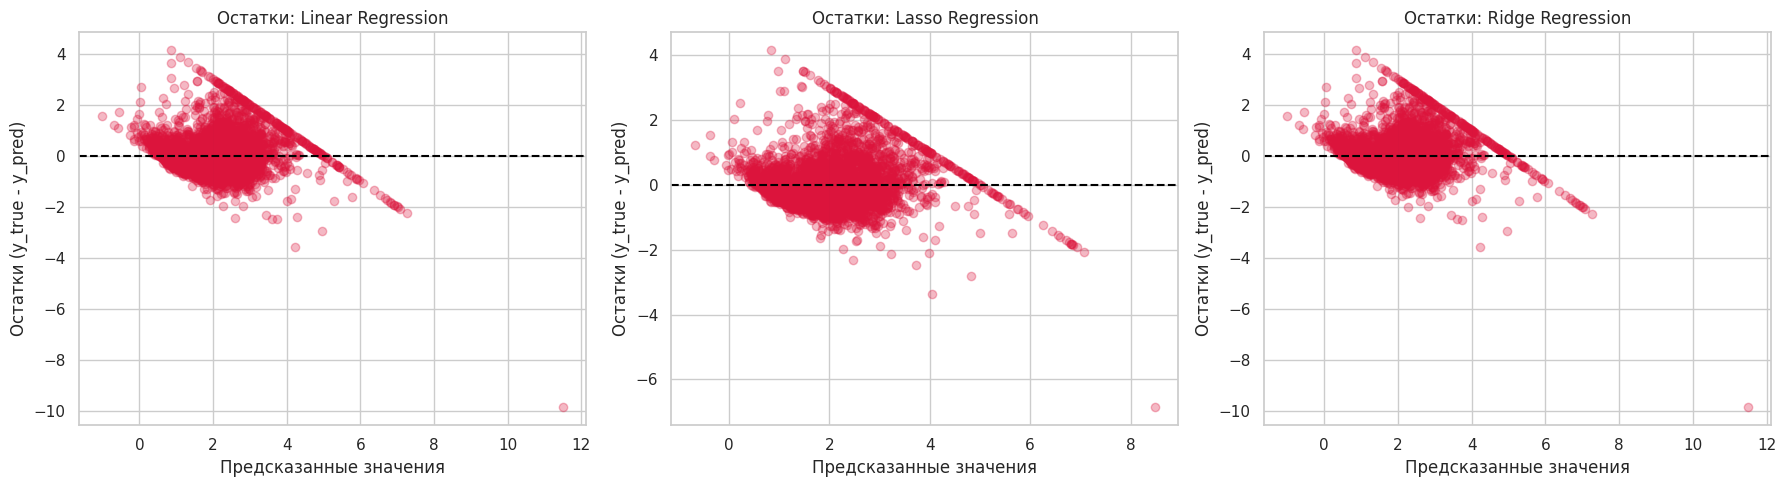

In [ ]:
# Построение графиков остатков для проверки гомоскедастичности
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (name, model) in enumerate(models.items()):
    y_pred = model.predict(X_test_scaled)
    residuals = y_test - y_pred

    axes[i].scatter(y_pred, residuals, alpha=0.3, color='crimson')
    axes[i].axhline(y=0, color='black', linestyle='--', linewidth=1.5)
    axes[i].set_title(f'Остатки: {name}')
    axes[i].set_xlabel('Предсказанные значения')
    axes[i].set_ylabel('Остатки (y_true - y_pred)')

plt.tight_layout()
plt.show()


### Пояснение к анализу остатков
График остатков используется для проверки условия гомоскедастичности. Горизонтальная пунктирная линия обозначает нуль. Если ошибки модели распределены случайно и с одинаковой дисперсией относительно нуля, предпосылка о гомоскедастичности выполняется.


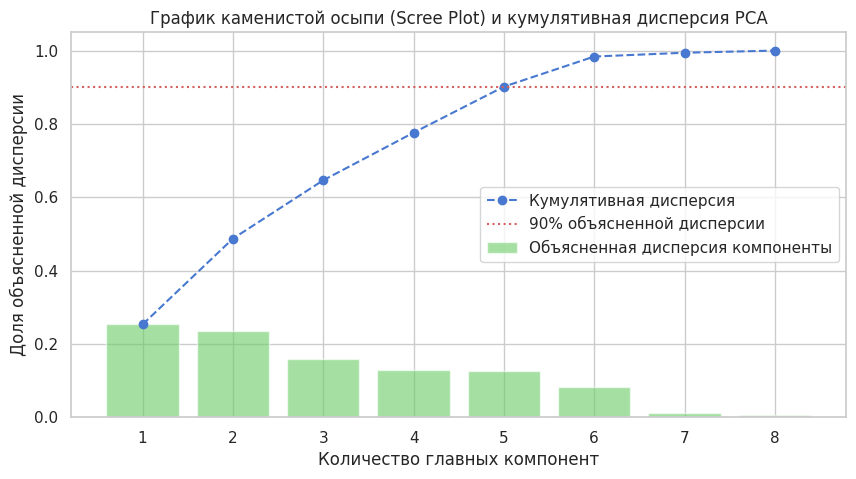

Количество компонент, объясняющих не менее 90% дисперсии: 5


In [ ]:
# Проведение PCA на стандартизированных признаках
pca_full = PCA().fit(X_train_scaled)

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(pca_full.explained_variance_ratio_) + 1),
         np.cumsum(pca_full.explained_variance_ratio_), marker='o', linestyle='--', color='b', label='Кумулятивная дисперсия')
plt.bar(range(1, len(pca_full.explained_variance_ratio_) + 1),
        pca_full.explained_variance_ratio_, alpha=0.6, color='g', label='Объясненная дисперсия компоненты')

plt.axhline(y=0.90, color='r', linestyle=':', label='90% объясненной дисперсии')
plt.xlabel('Количество главных компонент')
plt.ylabel('Доля объясненной дисперсии')
plt.title('График каменистой осыпи (Scree Plot) и кумулятивная дисперсия PCA')
plt.legend(loc='best')
plt.grid(True)
plt.show()

n_components_90 = np.argmax(np.cumsum(pca_full.explained_variance_ratio_) >= 0.90) + 1
print(f"Количество компонент, объясняющих не менее 90% дисперсии: {n_components_90}")

pca = PCA(n_components=n_components_90)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)


### Пояснение к методу главных компонент (PCA)
Метод главных компонент преобразует исходные признаки в набор ортогональных (некоррелированных) главных компонент. На графике каменистой осыпи показана доля объясняемой дисперсии. Выбрано минимальное количество компонент, покрывающее не менее 90% суммарной дисперсии, что снижает размерность и полностью устраняет мультиколлинеарность.


Сравнительная таблица всех моделей:


,Model,RMSE,R2,MAPE (%)
0,Linear Regression,0.745581,0.575788,31.952187
1,Lasso Regression,0.740442,0.581615,32.006636
2,Ridge Regression,0.745557,0.575816,31.951174
3,Linear Regression (PCA),0.862034,0.432923,41.193468
4,Lasso Regression (PCA),0.862027,0.432933,41.427938
5,Ridge Regression (PCA),0.862032,0.432925,41.194076


/tmp/ipykernel_2620/1302324365.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=comparison_df, x='Model', y=metric, ax=axes[i], palette='Blues_d')
/tmp/ipykernel_2620/1302324365.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45, ha='right')
/tmp/ipykernel_2620/1302324365.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=comparison_df, x='Model', y=metric, ax=axes[i], palette='Blues_d')
/tmp/ipykernel_2620/1302324365.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() o

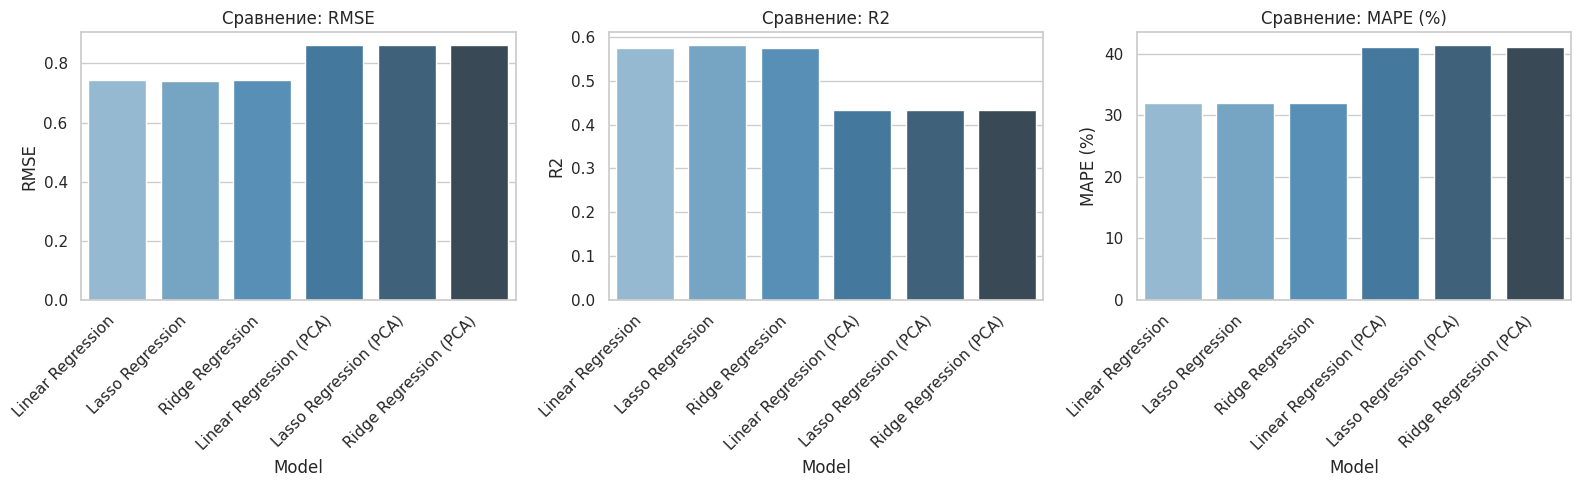

In [ ]:
# Обучение моделей на главных компонентах
results_pca = []

for name, model in models.items():
    model.fit(X_train_pca, y_train)
    y_pred_pca = model.predict(X_test_pca)
    rmse, r2, mape = evaluate_model(y_test, y_pred_pca)
    results_pca.append({'Model': f'{name} (PCA)', 'RMSE': rmse, 'R2': r2, 'MAPE (%)': mape})

results_pca_df = pd.DataFrame(results_pca)

# Объединение и сравнение результатов
comparison_df = pd.concat([results_base_df, results_pca_df], ignore_index=True)
print("Сравнительная таблица всех моделей:")
display(comparison_df)

# Наглядная визуализация сравнения метрик
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metrics = ['RMSE', 'R2', 'MAPE (%)']
for i, metric in enumerate(metrics):
    sns.barplot(data=comparison_df, x='Model', y=metric, ax=axes[i], palette='Blues_d')
    axes[i].set_title(f'Сравнение: {metric}')
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()


### Пояснение к сравнению результатов
Сравнительная таблица и столбчатые диаграммы показывают точность моделей до и после применения метода PCA. Использование главных компонент устраняет линейную зависимость между признаками при сохранении высокого уровня объясненной дисперсии ($R^2$).


## 2. Заключение и выводы

В ходе лабораторной работы:
1. Выполнена загрузка и комплексная предобработка датасета недвижимости.
2. Проведен корреляционный анализ и рассчитан показатель $VIF$, зафиксировавший наличие мультиколлинеарности.
3. Построены базовые линейные модели (Linear Regression, Lasso, Ridge), рассчитаны метрики качество ($RMSE$, $R^2$, $MAPE$) и построен график остатков.
4. Проведено снижение размерности методом главных компонент (PCA) с визуализацией каменистой осыпи.
5. Обучены регрессионные модели на главных компонентах. Сравнение метрик продемонстрировало, что PCA эффективно устраняет мультиколлинеарность, сохраняя высокую качество и упрощая признаковое пространство.

---

## 3. Список источников

1. Hastie, T., Tibshirani, R., & Friedman, J. (2009). *The Elements of Statistical Learning*. Springer.
2. James, G., Witten, D., Hastie, T., & Tibshirani, R. (2013). *An Introduction to Statistical Learning*. Springer.
3. Документация Scikit-Learn: https://scikit-learn.org/
4. Документация Statsmodels: https://www.statsmodels.org/
